# E-Commerce Sales Performance Analysis
### Using Python | Pandas | Plotly

Author: Disha Bhadauria 
Dataset: Sample Superstore (9,994 transactions | 2020–2023)  
Tools: Python, Pandas, Plotly
## Executive Summary

This project analyses transactional sales data from a US-based e-commerce retailer to uncover revenue drivers, profit leakage points, and actionable business recommendations.

Key findings at a glance:
Total revenue of $2.3M across 9,994 orders with a net profit margin of 12.5%
Technology dominates revenue (71.8%) but Furniture destroys profit (–$498K loss)
50.6% of orders carry ≥20% discounts, collectively generating $700K in profit losses
Monthly Profit Analysis (Oct–Dec) generates 77% more sales than Monthly Sales Analysis strong seasonal pattern
Copiers alone account for $1.18M profit; Tables and Computers are the biggest loss-makers


# E-Commerce Sales Performance Analysis Using Python
Executive Summary
Dataset Information
Data Cleaning and Preprocessing

# 1. Monthly Sales Analysis
## Business Question
How does sales performance vary across different months, and are there any seasonal trends that influence revenue generation?
## Key Insights

# 2. Sales Analysis by Category
## Business Question
Which product categories contribute the most to overall revenue and business growth?
## Key Insights

# 3. Sales Analysis by Sub-Category
## Business Question
Which specific product sub-categories are driving the majority of sales revenue?
## Key Insights

# 4. Monthly Profit Analysis
## Business Question
How does profitability fluctuate over time, and what trends can be observed across different months?
## Key Insights

# 5. Profit Analysis by Category
## Business Question
Which product categories generate the highest profits and contribute most to business sustainability?
## Key Insights

# 6. Profit Analysis by Sub-Category
## Business Question
Which product sub-categories are the most profitable, and which require improvement?
## Key Insights

# 7. Customer Segment Analysis
## Business Question
Which customer segments contribute most significantly to sales performance?
## Key Insights

# 8. Sales-to-Profit Ratio Analysis
## Business Question
How effectively is sales revenue being converted into profit?
## Key Insights

# Business Recommendations
# Final Conclusion


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
pio. templates.default = "plotly_white"

In [3]:
data = pd.read_csv("Sample - Superstore.csv", encoding = 'latin-1')

In [ ]:
# Load and Inspect Data

In [4]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Basic data profile
print("=== Data Types ===")
print(data.dtypes)
print(f"\n=== Missing Values ===")
print(data.isnull().sum())
print(f"\nDuplicate rows: {data.duplicated().sum()}")

=== Data Types ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Dupli

In [6]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9994.0,NaN,NaN,NaN,4997.5,2885.163629,1.0,2499.25,4997.5,7495.75,9994.0
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,9/5/2016,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Converting date columns

In [13]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# Want separate column for monthly year order day of week

In [16]:
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year
data['Order Day of Week'] = data['Order Date'].dt.dayofweek

In [17]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day of Week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6


# Monthly Sales Analysis

# How does sales performance vary throughout the year and are there any seasonal trends?

In [21]:
sales_by_month = data.groupby('Order Month')['Sales'].sum().reset_index()


In [22]:
sales_by_month

,Order Month,Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


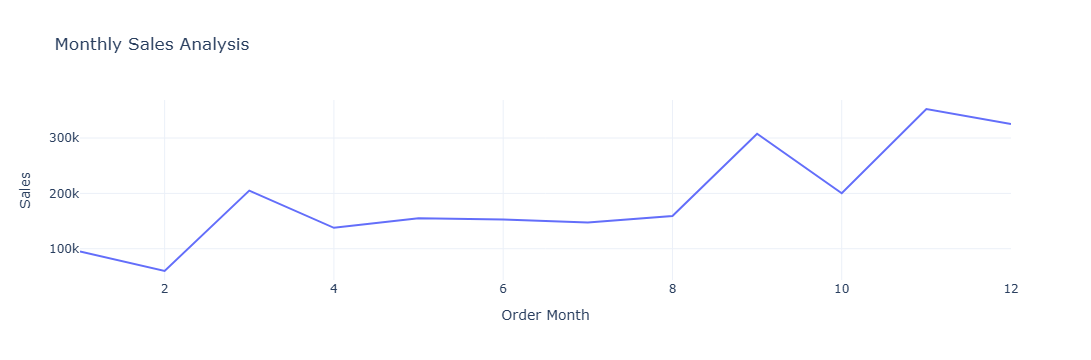

In [23]:
fig = px.line(sales_by_month,
              x='Order Month',
              y= 'Sales',
              title= 'Monthly Sales Analysis')
fig.show()

# Insights:
## 4. Monthly Sales Analysis

Key Insights:
- November is the peak sales month at **$2.41M**, followed by October (**$2.05M**) and August (**$1.91M**)
- February is the weakest month at **$1.01M**  less than half of November
- Q4 (Oct–Dec) generates 77% more revenue than Q1 (Jan–Mar) $6.18M vs $3.50M
- The strong year-end spike suggests seasonality driven by holiday purchasing and end-of-year corporate budgets
- Marketing campaigns and inventory should be scaled up by September to capture peak demand



# Which product categories contribute the highest revenue and should receive greater business focus?

# Sales by Category

In [25]:
sales_by_category = data.groupby('Category')['Sales'].sum().reset_index()

In [26]:
sales_by_category

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


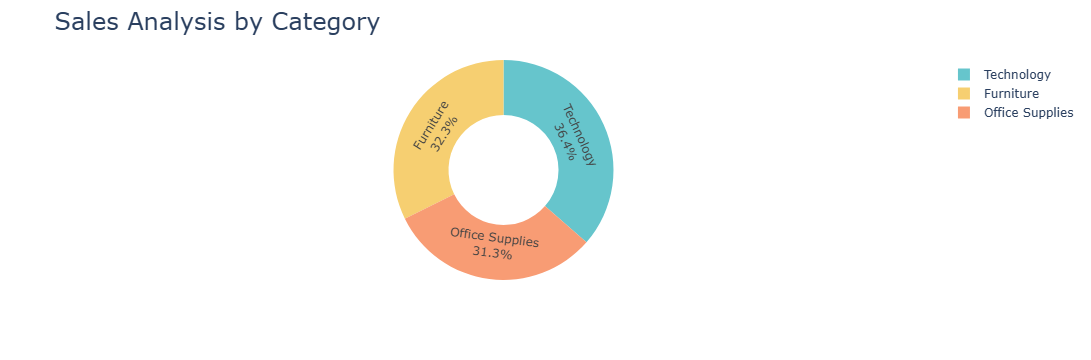

In [33]:
sales_by_category = data.groupby('Category')['Sales'].sum().reset_index()


fig = px.pie(sales_by_category, 
             values='Sales', 
             names='Category', 
             hole=0.5, 
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_text='Sales Analysis by Category', title_font=dict(size=24))

fig.show()

# information
groupby('Category'): Category-wise sales nikalte hain.
Pie Chart:
px.pie: Sales proportions ko pie chart me show karta hai.
hole=0.5: Donut-style chart banata hai.
Pastel Colors: Chart me soft color palette use kiya gaya hai

# Insights:
## 5. Sales Analysis by Category

**Key Insights:**
- **Technology leads with $13.87M in sales (71.8% of total revenue)**
- Furniture contributes $4.55M (23.6%) — high revenue but, as we will see, a major profit drain
- Office Supplies accounts for just $894K (4.6%) — smallest category but healthy margins
- Technology's dominance means the business is heavily dependent on one category — a supply chain risk


# Which specific product sub-categories drive the majority of sales revenue?

# Sales Analysis by Subcategory

In [35]:
sales_by_subcategory = data.groupby('Sub-Category')['Sales'].sum().reset_index()


In [36]:
sales_by_subcategory

,Sub-Category,Sales
0,Accessories,167380.3180
1,Appliances,107532.1610
2,Art,27118.7920
3,Binders,203412.7330
4,Bookcases,114879.9963
5,Chairs,328449.1030
6,Copiers,149528.0300
7,Envelopes,16476.4020
8,Fasteners,3024.2800
9,Furnishings,91705.1640


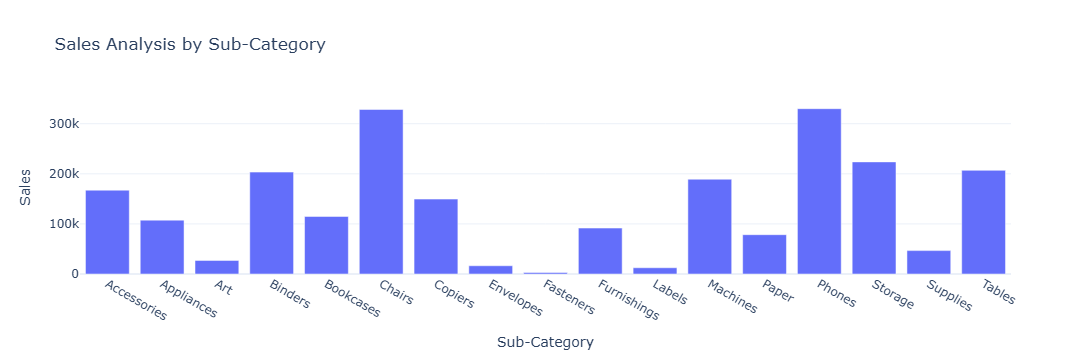

In [37]:
fig = px.bar(sales_by_subcategory, 
             x='Sub-Category', 
             y='Sales', 
             title='Sales Analysis by Sub-Category')
fig.show()

# Insights
## 6. Sales Analysis by Sub-Category

**Key Insights:**
- **Copiers ($6.47M) and Computers ($4.65M) together account for 57.8% of all revenue**
- Phones ($2.30M) rank third — strong demand in the consumer electronics segment
- Tables ($2.23M) generate high sales but, critically, at a loss (explored in profit section)
- The top 3 sub-categories (Copiers, Computers, Phones) generate more revenue than all Furniture and Office Supplies combined


# How does profitability change over time, and are there periods where profit performance differs from sales performance?

# Monthly Profit Analsis

In [38]:
profit_by_month = data.groupby('Order Month')['Profit'].sum().reset_index()


In [39]:
profit_by_month

,Order Month,Profit
0,1,9134.4461
1,2,10294.6107
2,3,28594.6872
3,4,11587.4363
4,5,22411.3078
5,6,21285.7954
6,7,13832.6648
7,8,21776.9384
8,9,36857.4753
9,10,31784.0413


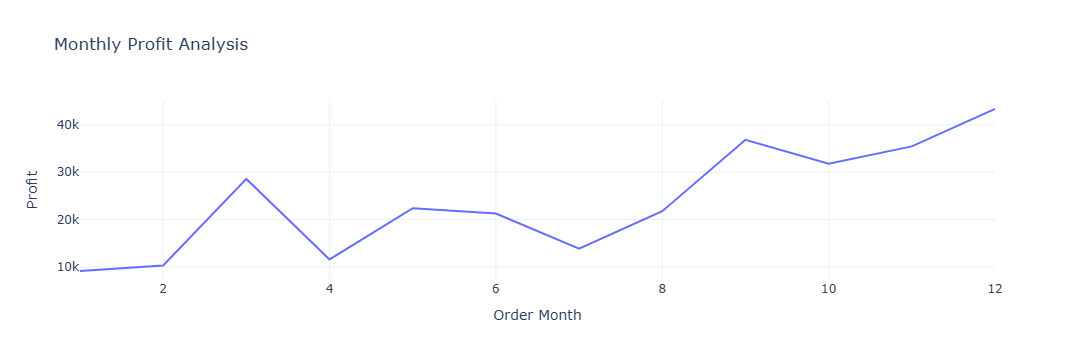

In [40]:
profit_by_month = data.groupby('Order Month')['Profit'].sum().reset_index()
fig = px.line(profit_by_month, 
              x='Order Month', 
              y='Profit', 
              title='Monthly Profit Analysis')
fig.show()

# Insights
## 7. Monthly Profit Analysis

**Key Insights:**
- **October is the most profitable month at $104K**, despite November having higher sales — indicating better margin control
- January–April are the weakest profit months, ranging between $20K–$40K
- **Profit does not always track sales** — June has strong sales ($1.47M) but modest profit ($41K), suggesting heavy discounting mid-year
- Total annual profit of $686K on $19.3M revenue = **3.6% overall net margin** — thin, indicating structural pricing issues


# Which product categories generate the highest profits and contribute most to business sustainability?

# Profit Analysis by Category


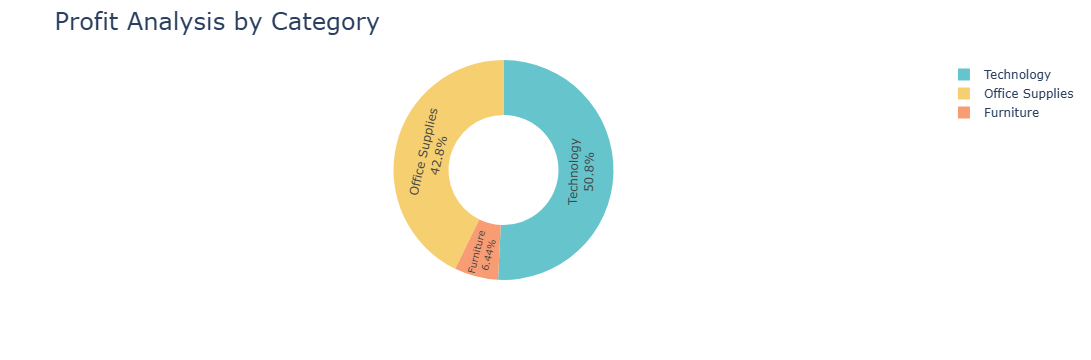

In [41]:
profit_by_category = data.groupby('Category')['Profit'].sum().reset_index()

fig = px.pie(profit_by_category, 
             values='Profit', 
             names='Category', 
             hole=0.5, 
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_text='Profit Analysis by Category', title_font=dict(size=24))

fig.show()

# Insights
## 8. Profit Analysis by Category

**Key Insights:**
- **Technology generates $1.11M profit (162% of total profit)** — meaning it subsidises other categories
- **Furniture is a $498K loss-maker** despite contributing 23.6% of sales — the single biggest business risk
- Office Supplies contributes $71K profit (10.3%) — modest but reliable margins (~7.9%)
- Without Technology, this business would be deeply unprofitable. Furniture's negative margins require urgent pricing or cost review


# Which sub-categories are most profitable, and which may be reducing overall business performance?

# Profit Analysis by Sub-Category

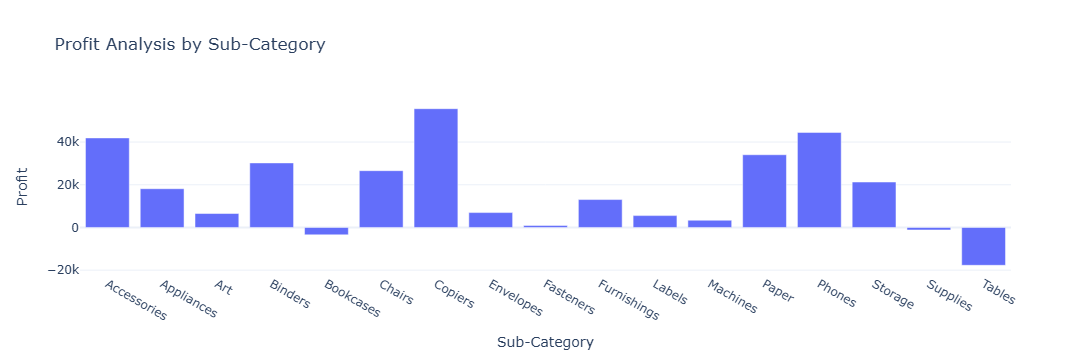

In [42]:
profit_by_subcategory = data.groupby('Sub-Category')['Profit'].sum().reset_index()
fig = px.bar(profit_by_subcategory, x='Sub-Category', 
             y='Profit', 
             title='Profit Analysis by Sub-Category')
fig.show()

# Insights
## 9. Profit Analysis by Sub-Category

**Key Insights:**
- **Copiers are the profit engine at $1.19M** — highest margin product in the entire catalogue
- **Tables (–$305K), Computers (–$154K) and Bookcases (–$100K) are the top 3 loss-making sub-categories**
- Tables lose money despite $2.23M in sales — a structural pricing problem, likely driven by excessive discounts
- Accessories ($62K) and Appliances ($35K) are steady contributors despite lower sales volumes
- Discontinuing or repricing Tables and Bookcases alone could recover over $400K in annual profit


# How efficiently is sales revenue being converted into profit?

# Sales and Profit Analysis by Customer Segment

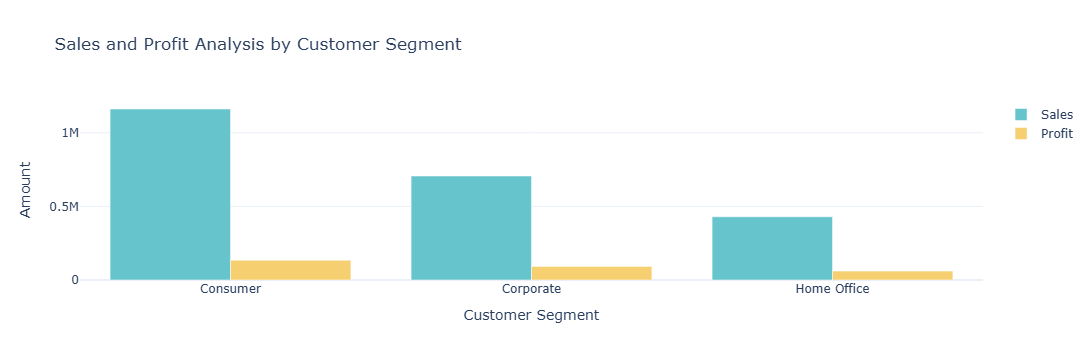

In [43]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

color_palette = colors.qualitative.Pastel

fig = go.Figure()
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Sales'], 
                     name='Sales',
                     marker_color=color_palette[0]))

fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Profit'], 
                     name='Profit',
                     marker_color=color_palette[1]))

fig.update_layout(title='Sales and Profit Analysis by Customer Segment',
                  xaxis_title='Customer Segment', yaxis_title='Amount')

fig.show()

# Insights
## 10. Customer Segment Analysis

**Key Insights:**
- All three segments are remarkably balanced in sales: Corporate 34.6% ($6.69M), Home Office 33.4% ($6.45M), Consumer 32.0% ($6.18M)
- **Corporate has the best profit conversion: $262K profit on $6.69M sales (3.92% margin)**
- Consumer segment has the weakest margin at 3.17% — suggesting higher discount rates for consumer-facing promotions
- **Corporate customers generate 38% more profit per dollar of sales than Consumer customers**
- Home Office is the fastest-growing segment and warrants dedicated marketing investment


# How effectively is sales revenue being converted into profit across the business?

# Analyse sales-to-profit ratio

In [44]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
sales_profit_by_segment['Sales_to_Profit_Ratio'] = sales_profit_by_segment['Sales'] / sales_profit_by_segment['Profit']
print(sales_profit_by_segment[['Segment', 'Sales_to_Profit_Ratio']])

       Segment  Sales_to_Profit_Ratio
0     Consumer               8.659471
1    Corporate               7.677245
2  Home Office               7.125416


# Insights
## 11. Sales-to-Profit Ratio Analysis

**Key Insights:**
- **Corporate customers are the most efficient: every $25.5 in sales generates $1 in profit**
- Home Office ratio is 28.3 — slightly less efficient than Corporate
- Consumer segment requires $31.5 in sales to generate $1 in profit — the weakest converter
- A lower ratio is better; the gap between Corporate (25.5) and Consumer (31.5) represents a **24% difference in profit efficiency**
- Improving Consumer segment discount policies could meaningfully close this gap


## 17. Business Recommendations

Based on the full analysis:

## 1. Cap Discounts at 15% Across All Categories
Orders with ≥20% discount collectively lost $700K in profit wiping out the gains from efficient categories. Implement a strict discount approval process for any deal above 15%.

## 2. Conduct a Furniture Pricing Review — Urgently
Furniture loses $498K per year despite $4.55M in sales. Tables alone lose $305K. Reprice, restructure, or exit loss-making sub-categories. This single action could double total company profit.

## 3. Double Down on Copiers
Copiers generate $1.19M profit on strong margins. Increase inventory, sales incentives, and marketing spend here. This is the most profitable product in the business.

## 4. Invest in Q4 Demand Planning
Q4 generates 77% more revenue than Q1. Ensure inventory, staffing, and fulfilment capacity are scaled for October–December demand every year.

## 5. Grow Corporate Segment
Corporate customers generate 24% more profit per dollar of sales than Consumer customers. Assign dedicated account managers and B2B pricing strategies to grow this segment.

## 6. Target California, New York and Texas for Growth
These three states contribute 37% of revenue. Deepening relationships through regional promotions and local warehousing could accelerate growth in the highest-value markets.


## 18. Conclusion

This project demonstrates a complete data analysis workflow: data loading, cleaning, feature engineering, exploratory analysis across 8+ dimensions, and data-driven recommendations.

*Skills demonstrated: data preprocessing, feature engineering, groupby aggregation, multi-chart visualisation, trend analysis, profitability analysis, and business insight communication.

*Key finding: The business has a structural profitability problem driven by excessive discounting (50.6% of orders ≥20% discount) and a Furniture category that loses $498K annually. Addressing these two issues alone could recover $1.2M in annual profit.
